#`Multi-Agent Ideation System`

##`Overview`

This notebook constructs an advanced Multi-Agent System (MAS) designed to simulate a corporate boardroom. Instead of a single AI brainstorming in isolation, this system employs a team of specialized agents who debate, critique, and refine business ideas to ensure they are viable, ethical, and strategic.

###`The Workflow`
The process follows a strict pipeline, visualized in the notebook's workflow diagram:

Analyst Agent: Based on the idea provided by the user, it searches the internet to find relvents facts and history.

Proponent: Based on the output provided the analyst agent it will create five alternative options about how the idea provided by the user can be expanded. It will send those ideas to the Devil's Advocate Agent and to the creative agent.  

Critique: A Devil's Advocate ruthlessly identifies risks and weakness of the idea provided by the Proponent agent and provide five counter ideas to the creative agent.

Synthesis: A Creative Agent merges these opposing views into refined five alternatives ideas and send to the three specialis agent to review and provide input.

Review: Specialist Agents (Strategist, Feasibility, Ethicist) validate the solutions against specific metrics and provide their input.

Reporting: An Executive Editor compiles a final, clean Markdown report.

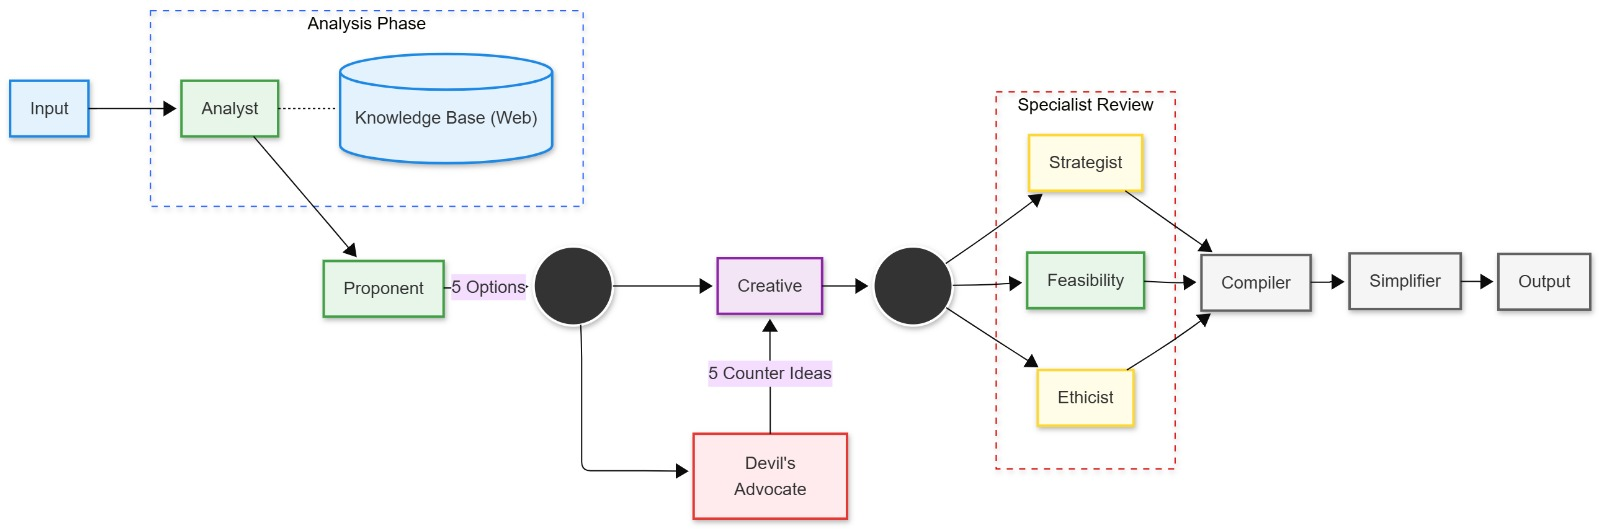

In [ ]:

!pip install -q -U crewai litellm langchain-community duckduckgo-search python-dotenv langchain-groq sentence-transformers scikit-learn ddgs

#Importing Dependencies



This cell imports all the necessary libraries required to build the Multi-Agent System. It brings together the Orchestration Framework (CrewAI), the User Interface (Gradio), and the Tooling (LangChain/DuckDuckGo) needed for the agents to function and interact with the world.

In [ ]:
import os
import logging
import gradio as gr
from textwrap import dedent
from crewai import Agent, Task, Crew, Process, LLM
from langchain_community.tools import DuckDuckGoSearchRun
from crewai.tools import BaseTool
from pydantic import BaseModel, Field
from google.colab import userdata
import numpy as np


#Configuring LLM and other tools

* LLM's are access through Openrouter
* Different LLM are set to serve the unique purposes of different agent
* Higher end 'gpt-4o-search-preview' has been used to levearge on its search speciality as we are using web search tool as a knowedge base.
* `anthropic/claude-haiku-4.5` is used as reasoning model for its high reasoning capability.
* `claude-3.7-sonnet:thinking` model is used for its creative upperhand over recent model.

* `claude-3.5-sonnet` is used for its speciality in ethical analysis
* `gpt-4o-mini` us used with large context size for formatting report

**🛠️ Environment & LLM Setup **

This section initializes the CrewAI environment and configures specialized LLMs via OpenRouter.
**PrerequisitesAPI Key:**

*  Ensure you have added your OPENROUTER_API_KEY to the Colab Secrets manager (Key icon on the left sidebar) and enabled notebook access.

* Configuration OverviewTelemetry:
 -  Disables CrewAI telemetry (CREWAI_TELEMETRY_OPT_OUT) to prevent interactive prompts from hanging the notebook.
* Logging: Writes execution logs to agent_workflow.log.

* Model Definitions: Initializes five distinct LLM profiles optimized for specific cognitive tasks:

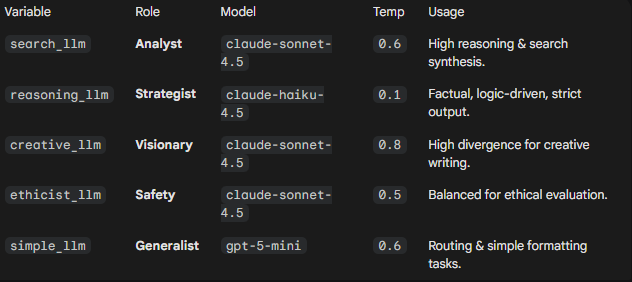

In [ ]:
import os
import logging
try:
    from google.colab import userdata
except ImportError:
    userdata = None

# 0. DISABLE CREWAI TELEMETRY & INTERACTIVE PROMPTS
# This is crucial! It prevents CrewAI from asking "Would you like to view traces?"
# and hiding the logs when it times out.
os.environ["CREWAI_TELEMETRY_OPT_OUT"] = "true"

# API SETUP
# Try to get key from Userdata (Colab Secrets) or Environment
api_key = None
if userdata:
    try:
        api_key = userdata.get("OPENROUTER_API_KEY")
    except Exception:
        pass

if not api_key:
    api_key = os.environ.get("OPENROUTER_API_KEY")

if not api_key:
    print("⚠️ OPENROUTER_API_KEY missing. Please add it to Colab Secrets (Key symbol on left).")
else:
    # CRITICAL FIX: Set the environment variable so litellm can find it
    os.environ["OPENROUTER_API_KEY"] = api_key
    print("OpenRouter key successfully loaded and set in environment.")

#  LOGGING SETUP
def setup_logging():
    logging.basicConfig(
        filename='agent_workflow.log',
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        force=True
    )
    return logging.getLogger("AgentLogger")

OpenRouter key successfully loaded and set in environment.


In [ ]:
##LLM configuration
# 1. API SETUP
# Try to get key from Userdata (Colab Secrets) or Environment
api_key = None
if userdata:
    try:
        api_key = userdata.get("OPENROUTER_API_KEY")
    except Exception:
        pass

if not api_key:
    api_key = os.environ.get("OPENROUTER_API_KEY")

if not api_key:
    print("⚠️ OPENROUTER_API_KEY missing. Please add it to Colab Secrets (Key symbol on left).")
else:
    # CRITICAL FIX: Set the environment variable so litellm can find it
    os.environ["OPENROUTER_API_KEY"] = api_key
    print("OpenRouter key successfully loaded and set in environment.")

#  LLMs per role
# gpt-4o model for high reasoning and speciality in search and analysis
search_llm = LLM(
    model="openrouter/anthropic/claude-sonnet-4.5", #updated model
    api_key=api_key,
    temperature=0.6, #0.6 suggested by justin
    max_tokens=2048,  # conservative for cost + control
    base_url="https://openrouter.ai/api/v1"
)

# # reasoning LLM for proponent creative, strategist and Devils'advocate
# (low temperature, factual, stable)
reasoning_llm = LLM(
    model="openrouter/anthropic/claude-haiku-4.5",
    api_key=api_key,
    temperature=0.1,
    max_tokens=2048,
    base_url="https://openrouter.ai/api/v1"
)
#reasoning model with higher temerature for unleashing creativity
creative_llm = LLM(
    model = "openrouter/anthropic/claude-sonnet-4.5",
    api_key=api_key,
    temperature=0.8, #0.8
    max_tokens=4096,
    base_url="https://openrouter.ai/api/v1"
)
#ethichis
ethicist_llm = LLM(
    model = "openrouter/anthropic/claude-sonnet-4.5", # calude 4.5 #safety model - llama 4 Gurd
    api_key=api_key,
    temperature=0.5, #.5
    max_tokens=4096,
    base_url="https://openrouter.ai/api/v1"
)
simple_llm = LLM(
    model = "openrouter/openai/gpt-5-mini", #5 mini
    api_key=api_key,
    temperature=0.6, #.6-.8
    max_tokens=8192,
    base_url="https://openrouter.ai/api/v1"
)


print("LLMs configuredn for search and intensive research and analyst kind of work")

OpenRouter key successfully loaded and set in environment.
LLMs configuredn for search and intensive research and analyst kind of work


In [ ]:
# DuckDuckGo search tool (CrewAI-compatible)
class DuckArgs(BaseModel):
    query: str = Field(..., description="The web search query")

class DuckDuckGoCrewTool(BaseTool):
    name: str = "duckduckgo_search"
    description: str = "Search the web for recent and relevant information using DuckDuckGo."
    args_schema: type[BaseModel] = DuckArgs

    def _run(self, query: str) -> str:
        return DuckDuckGoSearchRun().run(query)

# Knowledge Base helper
class KBArgs(BaseModel):
    topic: str = Field(..., description="Topic to retrieve guidance for")

class KnowledgeBaseTool(BaseTool):
    name: str = "knowledge_base"
    description: str = "Lightweight KB helper. Returns guidance and suggested queries for a topic."
    args_schema: type[BaseModel] = KBArgs

    def _run(self, topic: str) -> str:
        suggestions = [
            f"Topic: {topic}",
            "What to gather: market size, adoption trends, key vendors, compliance constraints, integration APIs, cost benchmarks.",
            "Search patterns: site:docs.google.com API docs; site:developer.* SDK auth; site:quickbooks.intuit.com API pricing."
        ]
        return "\n".join(suggestions)

# instantiate tools
search_tool = DuckDuckGoCrewTool()
kb_tool = KnowledgeBaseTool()

print("CrewAI tools ready.")


CrewAI tools ready.


#`The Agents Module`




Here we define the 8 agents. We enable memory=True so they remember context and inject the custom logger.

In [ ]:
def get_agents():
  #-- THE ANALYSTS --
    analyst = Agent(
        role="Market Analyst",
        goal="Analyze market data, history, and facts.",
        backstory="Expert data analyst focused on market reality.",
        tools=[search_tool],
        llm= search_llm,
        verbose=True,
        max_iter=10,
        handle_parsing_errors=True
    )

    proponent = Agent(
        role="Idea Proponent",
        goal="Generate 5 distinct expansion ideas based on market analysis.",
        backstory="Visionary optimist who sees potential everywhere.",
        llm=reasoning_llm,
        verbose=True,
        max_iter=10,
        handle_parsing_errors=True
    )

    devil = Agent(
        role="Devil's Advocate",
        goal="Generate strong counter-arguments for the proposed ideas.",
        backstory="Critical risk assessor who identifies failure points.",
        llm=reasoning_llm,
        verbose=True,
        max_iter=10,
        handle_parsing_errors=True

    )

    creative = Agent(
        role="Creative Director",
        goal="Synthesize Proponent ideas and Devil's critiques into refined concepts.",
        backstory="Master synthesizer who merges thesis and antithesis.",
        llm=creative_llm,
        verbose=True,
        max_iter=10,
        handle_parsing_errors=True
    )

    # -- THE SPECIALISTS --
    strategist = Agent(
        role="Chief Strategist",
        goal="Add strategic execution steps to the 5 options.",
        backstory="Focuses on 'How do we actually do this?'",
        llm=reasoning_llm,
        tools=[kb_tool],
        verbose=True,
        max_iter=10,
        handle_parsing_errors=True
    )

    ethicist = Agent(
        role="Ethics Officer",
        goal="Evaluate ethical implications of the 5 options.",
        backstory="Focuses on privacy, bias, and social impact.",
        llm=ethicist_llm,
        verbose=True,
        max_iter=10,
        handle_parsing_errors=True
    )

    feasibility = Agent(
        role="Technical Engineer",
        goal="Assess technical feasibility of the 5 options.",
        backstory="Focuses on stack, constraints, and reality.",
        llm=reasoning_llm,
        verbose=True,
        max_iter=10,
        handle_parsing_errors=True
    )

    # -- THE FINALIZERS --
    compiler = Agent(
        role="Strategic Synthesizer", # Changed to focus on synthesis
        goal="Synthesize specialist inputs into a concise, high-level summary. Avoid repetition.",
        backstory="Expert synthesizer who distills vast information into key strategic insights.",
        llm=simple_llm,
        verbose=True,
        max_iter=10,
        handle_parsing_errors=True
    )

    simplifier = Agent(
        role="Executive Editor", # Changed to focus on editing
        goal="Format the synthesized content into a punchy, readable Executive Summary.",
        backstory="Expert editor who cuts fluff and highlights value for busy executives.",
        llm=simple_llm,
        verbose=True,
        max_iter=10,
        handle_parsing_errors=True
    )

    return {
        "analyst": analyst, "proponent": proponent, "devil": devil,
        "creative": creative, "strategist": strategist, "ethicist": ethicist,
        "feasibility": feasibility, "compiler": compiler, "simplifier": simplifier
    }

#`🚀 Ideation System Orchestrator`
This function orchestrates a sequential multi-agent workflow to transform a raw topic into a comprehensive, strategic executive summary. It manages the lifecycle of tasks, data flow between agents, and automated logging.

**Core Function**

* run_ideation_system(topic: str) -> str

* Input: A user-defined topic string (e.g., "AI in Healthcare").

* Output: Returns the final Executive Summary generated by the simplifier agent.

* Side Effects: Generates timestamped .txt and .csv logs containing full agent interactions.

* Workflow Architecture
The system executes 9 sequential tasks, passing context forward to refine ideas iteratively:

* Analysis: Market & historical fact-finding.

* Expansion: Generating 5 distinct ideas based on analysis.

* Critique: "Devil's Advocate" review to find flaws.

* Synthesis: Merging ideas and critiques into refined options.

* Specialist Review (Parallel Context): *

* Strategy adds execution steps.

* Ethics reviews safety/compliance.

* Tech assesses feasibility.

* Compilation: Merging specialist inputs into a single draft.

* Formatting: Final polish into a Markdown Executive Summary.

**Logging System**b

The system uses a callback mechanism (log_agent_output) to capture every agent's raw output in real-time.

* TXT Log (log_output_TIMESTAMP.txt): A human-readable transcript of the entire session.

* CSV Log (log_output_TIMESTAMP.csv): A structured dataset useful for post-mortem analysis or fine-tuning models.

In [ ]:
import csv
from datetime import datetime

def run_ideation_system(topic):
    agents = get_agents()

    # Store individual agent outputs here
    agent_outputs_log = []

    def log_agent_output(task_output):
        """Callback to capture task results"""
        agent_outputs_log.append({
            "agent": task_output.agent,
            "description": task_output.description,
            "response": task_output.raw
        })

    # 1. ANALYSIS
    t1_analyze = Task(
        description=f"Analyze the market, history, and facts for: '{topic}'",
        expected_output="A Market Analysis Report.",
        agent=agents["analyst"]
    )

    # 2. EXPANSION
    t2_expand = Task(
        description="Based on analysis, generate exactly 5 Expansion Ideas.",
        expected_output="List of 5 Ideas.",
        agent=agents["proponent"],
        context=[t1_analyze]
    )

    # 3. CRITIQUE
    t3_critique = Task(
        description="Review the 5 Ideas. Provide strong counter-arguments (cons).",
        expected_output="Critique Report.",
        agent=agents["devil"],
        context=[t2_expand]
    )

    # 4. SYNTHESIS
    t4_synthesize = Task(
        description="Synthesize Ideas + Critiques into 5 Refined Options.",
        expected_output="List of 5 Refined Options.",
        agent=agents["creative"],
        context=[t2_expand, t3_critique]
    )

    # 5. SPECIALIST REVIEWS
    t5_strategy = Task(
        description="Add execution steps to the 5 Refined Options.",
        expected_output="Strategic input.",
        agent=agents["strategist"],
        context=[t4_synthesize]
    )

    t6_ethics = Task(
        description="Add ethical assessments to the 5 Refined Options.",
        expected_output="Ethical input.",
        agent=agents["ethicist"],
        context=[t4_synthesize]
    )

    t7_tech = Task(
        description="Add technical feasibility to the 5 Refined Options.",
        expected_output="Technical input.",
        agent=agents["feasibility"],
        context=[t4_synthesize]
    )

    # 6. COMPILATION
    t8_compile = Task(
        description="Compile Strategy, Ethics, and Tech inputs into a summarized draft. Focus on the 'So What?' and remove repetitive sections.",
        expected_output="Summarized Draft.",
        agent=agents["compiler"],
        context=[t5_strategy, t6_ethics, t7_tech]
    )

    t9_format = Task(
        description=f"Format into a concise Executive Summary in Markdown. Generate a concise and meaningful title for the executive summary that clearly reflects the user's initial idea: '{topic}'. Use bullet points and headers. Keep the total length under 1,500 words. Prioritize readability.",
        expected_output="Concise Executive Summary.",
        agent=agents["simplifier"],
        context=[t8_compile]
    )

    # CREW ASSEMBLY
    crew = Crew(
        agents=list(agents.values()),
        tasks=[t1_analyze, t2_expand, t3_critique, t4_synthesize,
               t5_strategy, t6_ethics, t7_tech, t8_compile, t9_format],
        process=Process.sequential,
        verbose=True,
        task_callback=log_agent_output # Hook up the logging callback
    )

    result = crew.kickoff()

    # --- FILE GENERATION ---
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    txt_filename = f"log_output_{timestamp}.txt"

    # Generate TXT Log
    try:
        with open(txt_filename, "w", encoding="utf-8") as f:
            for entry in agent_outputs_log:
                f.write(f"--- Agent: {entry['agent']} ---\n")
                f.write(f"Task: {entry['description']}\n")
                f.write(f"Response:\n{entry['response']}\n")
                f.write("="*80 + "\n\n")
        print(f"\n✅ Generated detailed TXT log: {txt_filename}")
    except Exception as e:
        print(f"❌ Error writing TXT log: {e}")

    return result, txt_filename

## Gradio Interface Setup and Launch

This cell is responsible for setting up and launching the Gradio web interface for the Multi-Agent Ideation System. It includes the following functionalities:

1.  **Google Drive Integration:** It mounts your Google Drive to enable saving reports and logs directly to a designated folder (`/content/drive/My Drive/Agent_Reports`). This ensures persistence and easy access to the generated outputs.
2.  **Custom Logging:** A `LoggerWriter` class is implemented to capture all console output (stdout) and redirect it to both the terminal and a local log file (`agent_workflow.log`). This allows for a comprehensive record of the agent's execution steps and any messages.
3.  **Log Reading Function:** The `read_logs()` function is defined to retrieve and display the content of the `agent_workflow.log` file within the Gradio interface.
4.  **Drive Saving Function:** The `save_to_drive(topic)` function handles copying the generated markdown report (`final_report.md`) and the `agent_workflow.log` file to Google Drive. It also backs up individual agent logs (like `log_output_*.txt` and `log_output_*.csv`) for each run, ensuring all detailed outputs are stored.
5.  **Report Generation Function (`generate_report`):** This is the core function that orchestrates the entire ideation process:
    *   It clears any previous `final_report.md` and old individual agent log files.
    *   It temporarily redirects `sys.stdout` to the `LoggerWriter` for comprehensive logging.
    *   It calls `run_ideation_system(topic)` to kick off the CrewAI process with the user-provided business idea.
    *   It saves the final executive summary (markdown) locally and then to Google Drive using `save_to_drive()`.
    *   It handles potential errors during the execution and restores the original `sys.stdout` in a `finally` block.
6.  **Gradio Interface Definition:** Using `gr.Blocks`, it creates a user-friendly interface with:
    *   An **"Ideation Studio"** tab where users can input a business idea, run the ideation process, and view/download the final report.
    *   An **"Agent Logs"** tab to display real-time and historical logs of the agent's activities.
7.  **Launch:** Finally, `demo.launch(share=True, debug=True)` starts the Gradio server, making the interface accessible via a public URL and enabling debug mode for detailed output in the Colab environment.

In [ ]:
import gradio as gr
import os
import sys
import shutil
import time
import glob
from google.colab import drive

# 1. MOUNT GOOGLE DRIVE
# This will trigger an authentication prompt the first time it runs
if not os.path.exists('/content/drive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

# Define Drive Save Location
DRIVE_FOLDER = "/content/drive/My Drive/Ideation_System_Reports"
os.makedirs(DRIVE_FOLDER, exist_ok=True)

REPORT_FILE_NAME = "final_report.md"
LOG_FILE_NAME = "agent_workflow.log"

# Custom Logger to write to both Terminal and File
class LoggerWriter:
    def __init__(self, filename, original_stdout):
        self.terminal = original_stdout # Store the original stdout
        self.filename = filename
        # Changed "w" to "a" to append logs instead of overwriting
        self.log_file = open(filename, "a", buffering=1)

    def write(self, message):
        self.terminal.write(message)
        self.log_file.write(message)
        self.log_file.flush()

    def flush(self):
        self.terminal.flush()
        self.log_file.flush()

    def isatty(self):
        # Delegate isatty to the original terminal if it exists, otherwise return False
        if hasattr(self.terminal, 'isatty'):
            return self.terminal.isatty()
        return False

    def close(self):
        self.log_file.close()

def read_logs():
    if os.path.exists(LOG_FILE_NAME):
        with open(LOG_FILE_NAME, "r") as f:
            # Removed truncation to show the whole log
            return f.read()
    return "No logs yet..."

def save_to_drive(topic):
    """Copies local report and log to Google Drive with timestamp."""
    try:
        # Sanitize topic for filename
        safe_topic = "".join([c if c.isalnum() else "_" for c in topic])[:50]
        timestamp = time.strftime("%Y%m%d-%H%M%S")

        drive_report = os.path.join(DRIVE_FOLDER, f"Report_{timestamp}_{safe_topic}.md")
        drive_log = os.path.join(DRIVE_FOLDER, f"Log_{timestamp}_{safe_topic}.txt")

        shutil.copy(REPORT_FILE_NAME, drive_report)
        shutil.copy(LOG_FILE_NAME, drive_log)

        # --- NEW: Backup individual agent logs ---
        copied_logs = []
        # Find logs generated in the last run
        for log_file in glob.glob("log_output_*"):
            # Prefix with topic for easier organization in Drive
            dest_path = os.path.join(DRIVE_FOLDER, f"{safe_topic}_{log_file}")
            shutil.copy(log_file, dest_path)
            copied_logs.append(log_file)

        print(f"\n✅ Backup saved to Drive: {drive_report}")
        if copied_logs:
            print(f"✅ Individual Agent Logs saved: {', '.join(copied_logs)}")

        return f"Saved to: {drive_report}"
    except Exception as e:
        print(f"\n⚠️ Drive Save Failed: {e}")
        return f"Drive Save Failed: {e}"

def generate_report(topic):
    # Clear previous report
    if os.path.exists(REPORT_FILE_NAME):
        os.remove(REPORT_FILE_NAME)

    # Clear previous log file for a clean start to the new run
    if os.path.exists(LOG_FILE_NAME):
        with open(LOG_FILE_NAME, "w") as f:
            f.write("") # Clear content

    # Clean up old log output files to keep directory clean (optional, but good practice)
    for old_log in glob.glob("log_output_*"):
        try:
            os.remove(old_log)
        except:
            pass

    # Start capturing stdout
    original_stdout = sys.stdout
    sys.stdout = LoggerWriter(LOG_FILE_NAME, original_stdout) # Pass original_stdout here

    try:
        # Separator to distinguish runs in the appended log
        print(f"\n\n{'='*40}\n🚀 NEW RUN: {topic}\n{'='*40}\n")

        # Run the system
        result, txt_log_path = run_ideation_system(topic)
        final_report_content = str(result)

        # Save the final report locally
        with open(REPORT_FILE_NAME, "w") as f:
            f.write(final_report_content)

        # AUTO-SAVE TO DRIVE
        save_msg = save_to_drive(topic)

        # Return report, logs, and file paths for download buttons
        return final_report_content, read_logs(), REPORT_FILE_NAME, txt_log_path

    except Exception as e:
        print(f"\n❌ ERROR: {str(e)}")
        # Ensure log file is returned even on error to show error in UI and for download
        return f"Error: {str(e)}", read_logs(), None, None

    finally:
        # Restore stdout and close log file safely
        if isinstance(sys.stdout, LoggerWriter):
            sys.stdout.close()
            sys.stdout = original_stdout

In [ ]:

# --- THEME SETUP ---
corporate_theme = gr.themes.Soft(
    primary_hue="slate",
    secondary_hue="gray",
    font=[gr.themes.GoogleFont("Inter"), "ui-sans-serif", "system-ui"]
).set(
    button_primary_background_fill="#1e293b", # Dark Slate
    block_shadow="0 4px 6px -1px rgba(0, 0, 0, 0.1)"
)
with gr.Blocks(theme=corporate_theme, title="Strategic Intelligence Boardroom") as demo:
  with gr.Row():
        with gr.Column(scale=4):
            gr.Markdown("## 🏢 MindStein:Strategic Intelligence Boardroom")
            gr.Markdown("*Multi-Agent Corporate Simulation System*")
        with gr.Column(scale=1):
             gr.Markdown("🟢 **System Online**")
    # 💡 (Lightbulb - Ideation)
    # 🧠 (Brain - Intelligence)
    # 🤖 (Robot - Agents)
    # ⚙️ (Gear - Workflow)
    # ✨ (Spark - Creativity)


  with gr.Tabs():
      with gr.TabItem("💡 Ideation Studio"):
          with gr.Row():
              with gr.Column(scale=4):
                  idea_input = gr.Textbox(label="Business Idea", lines=5, placeholder="e.g. Drone Coffee Delivery")
                  # Updated button to match non-rocket theme
                  run_btn = gr.Button("▶️ Run Ideation", variant="primary")

              with gr.Column(scale=4):
                  report_output = gr.Markdown(label="Final Report")

              with gr.Column(scale=1):
                  gr.Markdown("### 📥 Downloads")
                  download_report_btn = gr.File(label="Download Final Report", file_count="single", interactive=False)
                  download_txt_btn = gr.File(label="Download Agent Logs (TXT)", file_count="single", interactive=False)

      with gr.TabItem("🤖 Agent Logs"):
          log_btn = gr.Button("🔄 Refresh Logs")
          log_output = gr.Textbox(label="Logs", lines=20, interactive=False)

  run_btn.click(
      fn=generate_report,
      inputs=idea_input,
      outputs=[report_output, log_output, download_report_btn, download_txt_btn]
  )
  log_btn.click(fn=read_logs, outputs=log_output)

# Launch
print("Starting Gradio...")
# debug=True: Keeps cell running, prints errors to Colab.
# debug=False: Cell finishes, app runs in background (Logs still work in UI!)
demo.launch(share=True, debug=True)

/tmp/ipython-input-3338806670.py:10: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=corporate_theme, title="Strategic Intelligence Boardroom") as demo:


Starting Gradio...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c2d0cd9e044f4e3302.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)




🚀 NEW RUN: A workplace productivity software that uses laptop webcams to track employee eye movements and emotional states, automatically docking their pay if they look away from the screen for more than 5 minutes per hour.



╭──────────────────────────────────────────── Crew Execution Started ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 4d80739b-b7d1-4f00-9ae1-7ad42e2efd4d                                                                       │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Market Analyst                                                                                          │
│                                                                                                                 │
│  Task: Analyze the market, history, and facts for: 'A workplace productivity software that uses laptop webcams  │
│  to track employee eye movements and emotional states, automatically docking their pay if they look away from   │
│  the screen for more than 5 minutes per hour.'                                                                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Executive Editor                                                                                        │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  # Executive Summary — Assessment: Webcam-Based Gaze & Emotion Tracking with Automatic Pay Docking              │
│                                                                                                                 │
│  Short framing (So what?)                                                                                       │
│  - The proposed product—using laptop webcams to track gaze and emotional states and automatically docking pay   │
│  if an employee looks away >5 minutes/hour—is commercially plausible but ethically, legally, and operationally  │
│  high-risk. It trades short-term monitoring gains for severe reputational, compliance, and workforce-cost       │
│  risks.                                                                                                         │
│  - Practical alternative: pivot toward ethically defensible, high-value features (employee-owned insights,      │
│  accessibility, contextual analytics) that deliver productivity value without coercive surveillance. The        │
│  portfolio below evaluates five refined options and gives clear action recommendations.                         │
│                                                                                                                 │
│  Top-line recommendation                                                                                        │
│  - Do not pursue the pay-docking webcam surveillance as described. Instead, prioritize Option 2                 │
│  (Employee-Owned Performance Insights) and Option 5 (Workplace Accessibility & Accommodation Platform) in       │
│  parallel. Treat Option 1 (Integrated Project Intelligence) as a conditional enterprise bet if strict privacy   │
│  and partner commitments are secured. Hold Options 3 and 4 for very specific, governed customers.               │
│                                                                                                                 │
│  Options — concise, action-oriented briefs                                                                      │
│                                                                                                                 │
│  Option 1 — Integrated Project Intelligence Platform (Contextual Productivity Insights)                         │
│  - What: Middleware analytics copilot that explains WHY metrics move across Jira/Asana/Monday. SaaS pricing     │
│  $150–$400/employee/year; platform revenue-share distribution.                                                  │
│  - So what?: High enterprise demand if positioned as explanatory (not punitive). Major revenue potential but    │
│  risks of sliding into individual surveillance.                                                                 │
│  - Ethics: Moderate concern — surveillance and bias risks. Mitigations: data minimization, short retention      │
│  (90–180 days), human-in-the-loop review, transparency dashboards, contractual limits.                          │
│  - Tech feasibility: High (8/10). 12–18 months to MVP; 8–12 engineers; infra $15–30k/mo.                        │
│  - Execution (quick phases): Build read-only connectors and baseline models (Months 1–4); deliver MVP with      │
│  Jira + VP Sales hire (5–8); expand integrations & benchmarking (9–24).                                         │
│  - Verdict: Pursue only with platform partnerships and 

Output()


✅ Generated detailed TXT log: log_output_2025-12-09_00-48-26.txt


╭──────────────────────────────────────────────── Task Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: a7d07e63-eda8-4a01-aa0f-47b49096a125                                                                     │
│  Agent: Executive Editor                                                                                        │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


✅ Backup saved to Drive: /content/drive/My Drive/Ideation_System_Reports/Report_20251209-004826_A_workplace_productivity_software_that_uses_laptop.md
✅ Individual Agent Logs saved: log_output_2025-12-09_00-48-26.txt


At its heart, MindStein operates through a CrewAI orchestration, where 9 specialized AI agents work in sequence. The process begins with our Market Analyst, powered by Claude-sonnet-4.5 and DuckDuckGo, unearthing crucial market data. Next, the Idea Proponent (Claude-haiku-4.5) crafts five distinct expansion ideas. These ideas are then rigorously challenged by the Devil's Advocate (Claude-haiku-4.5), identifying potential risks and counter-arguments.

The Creative Director (Claude-sonnet-4.5) synthesizes these opposing views into five refined concepts. These concepts then undergo parallel scrutiny by our specialists: the Chief Strategist (Claude-haiku-4.5) adds execution steps, the Ethics Officer (Claude-sonnet-4.5) evaluates moral implications, and the Technical Engineer (Claude-haiku-4.5) assesses feasibility. All of them uses the KnowledgeBaseTool to provide granular feedback.

Finally, the Strategic Synthesizer (GPT-5-mini) compiles these specialist insights into a cohesive draft, which the Executive Editor (GPT-5-mini) polishes into a concise, Markdown-formatted executive summary. Throughout, OpenRouter.ai facilitates flexible LLM selection, ensuring each agent—from the research-heavy Claude-sonnet-4.5 to the precise Claude-haiku-4.5 and the efficient GPT-5-mini—is optimally equipped.

### 🧪 **Test Prompts for your Multi-Agent System**

Once you run the code cells above and the Gradio interface launches, copy and paste these prompts into the **"Business Idea"** box to see how your agents perform:

1.  **AI-Powered Personal Nutritionist**
    > "An app that uses computer vision to track food intake and generates personalized meal plans based on DNA and microbiome data."
    *   *Why test this?* Challenges the **Ethicist** (privacy/data) and **Technical Engineer** (CV accuracy).

2.  **Drone-Based Home Maintenance**
    > "A subscription service where drones autonomously inspect home exteriors (roofs, gutters) for damage and deploy repair bots for minor fixes."
    *   *Why test this?* Good for the **Devil's Advocate** (safety regulations) and **Strategist** (operational rollout).

3.  **Sustainable Packaging for E-commerce**
    > "A circular economy platform providing reusable packaging for major online retailers, including reverse logistics for collection and cleaning."
    *   *Why test this?* Tests the **Market Analyst** (logistics costs vs single-use) and **Proponent** (sustainability trends).

4.  **VR Education for Medical Students**
    > "A fully immersive VR platform allowing medical students to practice surgeries with haptic feedback, collaborating globally in real-time."
    *   *Why test this?* Challenges the **Technical Engineer** (latency/haptics) and **Market Analyst** (adoption barriers).

5.  **Blockchain Identity for Refugees**
    > "A decentralized identity system for displaced persons to store credentials and medical records securely without reliance on a specific government."
    *   *Why test this?* Heavy focus for the **Ethicist** (data sovereignty) and **Strategist** (NGO partnerships).